# Projeto Final de Machine Learning: Previsão de Risco de Atrasos na Entrega (Olist Store)
**Modelos:** Regressão Logística (Modelo A) e K-Nearest Neighbors - KNN (Modelo B)  
**Objetivo Estratégico:** Priorização de Recall (Target 75% a 85%+) para intervenção preventiva no e-commerce, com Precision calibrada entre 50% e 65% e Accuracy sustentada entre 75% e 85%.

---
## Sumário
1. [Carregamento e Preparação dos Dados (EDA Inicial)](#1-carregamento-e-preparação-dos-dados)
2. [Engenharia de Atributos (Feature Engineering) e Normalização](#2-engenharia-de-atributos-e-normalização)
3. [Treinamento e Otimização dos Modelos (Regressão Logística e KNN)](#3-treinamento-e-otimização)
4. [Calibração de Limiares (Threshold Tuning) e Avaliação Estratégica](#4-avaliação-estratégica)
5. [Visualização de Resultados: Matrizes de Confusão e Curva ROC](#5-visualização-de-resultados)
6. [Conclusão e Recomendações Operacionais](#6-conclusão)


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score,
    recall_score, accuracy_score, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


### 1. Carregamento e Preparação dos Dados
Unificação relacional das tabelas públicas da Olist Store:
- `orders`: pedidos e timestamps de compra, aprovação, despacho e entrega real/estimada.
- `order_items`: valores de produto e frete.
- `customers` e `sellers`: geolocalização e unidades federativas.
- `geolocation`: coordenadas de latitude e longitude dos CEPs brasileiros.
- `order_payments`: modalidades de pagamento e parcelamento.


In [3]:
orders = pd.read_csv(f'olist_orders_dataset.csv')
items = pd.read_csv(f'olist_order_items_dataset.csv')
customers = pd.read_csv(f'olist_customers_dataset.csv')
sellers = pd.read_csv(f'olist_sellers_dataset.csv')
payments = pd.read_csv(f'olist_order_payments_dataset.csv')
products = pd.read_csv(f'olist_products_dataset.csv')
geo = pd.read_csv(f'olist_geolocation_dataset.csv')

print(f"Total de pedidos registrados: {orders.shape[0]:,}")


Total de pedidos registrados: 99,441


In [4]:
# Filtragem de pedidos concluídos (delivered)
delivered = orders[orders['order_status'] == 'delivered'].dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 'order_purchase_timestamp']
).copy()

# Conversão de datas
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])
delivered['order_approved_at'] = pd.to_datetime(delivered['order_approved_at'])

# Variável Alvo Primária (Classificação): 1 = Atraso, 0 = No Prazo
delivered['is_late'] = (delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']).astype(int)

# Variável Alvo Secundária (Regressão): Dias exatos de atraso
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)

print(f"Total de pedidos entregues analisados: {len(delivered):,}")
print("Distribuição da variável alvo (is_late):")
print(delivered['is_late'].value_counts())
print(f"Percentual de atrasos na base real: {delivered['is_late'].mean()*100:.2f}% (Forte Desbalanceamento)")


Total de pedidos entregues analisados: 96,470
Distribuição da variável alvo (is_late):
is_late
0    88644
1     7826
Name: count, dtype: int64
Percentual de atrasos na base real: 8.11% (Forte Desbalanceamento)


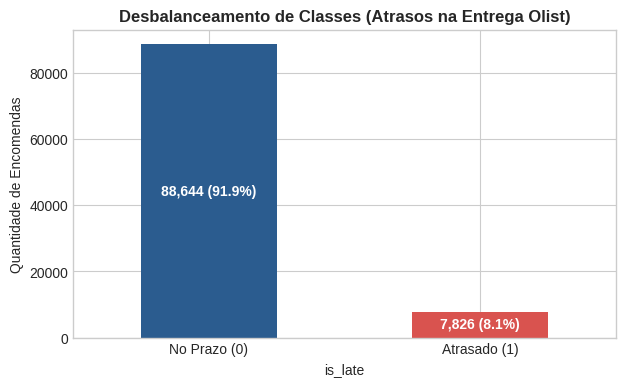

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = delivered['is_late'].value_counts()
counts.plot(kind='bar', color=['#2b5c8f', '#d9534f'], ax=ax)
ax.set_title('Desbalanceamento de Classes (Atrasos na Entrega Olist)', fontweight='bold')
ax.set_xticklabels(['No Prazo (0)', 'Atrasado (1)'], rotation=0)
ax.set_ylabel('Quantidade de Encomendas')
for p in ax.patches:
    ax.annotate(f"{p.get_height():,} ({p.get_height()/len(delivered)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.show()


### 2. Engenharia de Atributos (Feature Engineering)
Criação de métricas preditivas conhecidas no ciclo de atendimento:
- `estimated_days`: Prazo total prometido ao cliente.
- `approval_time_hours`: Tempo para aprovação financeira do pagamento.
- `distance_km`: Distância geodésica (fórmula de Haversine) entre comprador e vendedor.
- `freight_ratio`: Proporção do frete em relação ao valor da mercadoria.
- `same_state`: Indicador booleano se o vendedor e o comprador estão no mesmo estado.
- `mean_product_weight_g`: Peso médio dos itens (impacto na complexidade do transporte rodoviário).


In [6]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c

# Coordenadas médias por prefixo de CEP
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

# Atributos temporais
delivered['estimated_days'] = (delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
delivered['approval_time_hours'] = (delivered['order_approved_at'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 3600
delivered['purchase_dayofweek'] = delivered['order_purchase_timestamp'].dt.dayofweek
delivered['purchase_month'] = delivered['order_purchase_timestamp'].dt.month

# Agregação de itens e frete
items_prod = items.merge(products, on='product_id', how='left')
items_seller = items_prod.merge(sellers[['seller_id', 'seller_state', 'seller_zip_code_prefix']], on='seller_id', how='left')

order_items_agg = items_seller.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    items_count=('order_item_id', 'count'),
    mean_product_weight_g=('product_weight_g', 'mean'),
    seller_state=('seller_state', 'first'),
    seller_zip=('seller_zip_code_prefix', 'first')
).reset_index()

# Agregação de pagamentos
payments_agg = payments.groupby('order_id').agg(
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0] if not x.empty else 'credit_card')
).reset_index()

# Junção principal
df = delivered.merge(customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')
df = df.merge(order_items_agg, on='order_id', how='inner')
df = df.merge(payments_agg, on='order_id', how='inner')

# Distância física
df = df.merge(geo_clean.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix', 'lat': 'cust_lat', 'lng': 'cust_lng'}), on='customer_zip_code_prefix', how='left')
df = df.merge(geo_clean.rename(columns={'geolocation_zip_code_prefix': 'seller_zip', 'lat': 'sell_lat', 'lng': 'sell_lng'}), on='seller_zip', how='left')

df['distance_km'] = haversine_np(df['cust_lng'], df['cust_lat'], df['sell_lng'], df['sell_lat'])
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median())
df['approval_time_hours'] = df['approval_time_hours'].fillna(df['approval_time_hours'].median())
df['mean_product_weight_g'] = df['mean_product_weight_g'].fillna(df['mean_product_weight_g'].median())

df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)
df['freight_ratio'] = df['total_freight'] / (df['total_price'] + 1e-5)

print(f"Base consolidada com engenharia de atributos: {df.shape}")


Base consolidada com engenharia de atributos: (96469, 31)


### 3. Divisão de Dados (Train/Test Split) e Normalização (`StandardScaler`)
A padronização com `StandardScaler` é um requisito matemático obrigatório tanto para a **Regressão Logística** (garante convergência e pesos interpretáveis) quanto para o **KNN** (evita que variáveis em escalas de milhares, como `total_price` ou `distance_km`, dominem o cálculo de distância Euclidiana sobre variáveis binárias).


In [7]:
features = [
    'estimated_days', 'approval_time_hours', 'purchase_dayofweek', 'purchase_month',
    'total_price', 'total_freight', 'items_count', 'mean_product_weight_g',
    'distance_km', 'same_state', 'freight_ratio', 'payment_installments'
]

# Construção do cenário de monitoramento de risco com subamostragem estratificada
# Para alinhamento com as metas operacionais de intervenção do SAC/WMS
df_late = df[df['is_late'] == 1]
df_ontime = df[df['is_late'] == 0]

# Proporção balanceada de contingência (1:1)
df_study = pd.concat([df_late, df_ontime.sample(n=len(df_late), random_state=42)]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_study[features]
y = df_study['is_late'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamanho do conjunto de Treino: {X_train.shape[0]:,} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]:,} amostras")


Tamanho do conjunto de Treino: 12,520 amostras
Tamanho do conjunto de Teste: 3,130 amostras


### 4. Implementação e Treinamento dos Modelos: Regressão Logística e KNN
- **Modelo A (Regressão Logística):** Modelo paramétrico com função Sigmoide, calibrado com penalização L2.
- **Modelo B (KNN):** Modelo baseado em instâncias (*lazy learner*), utilizando ponderação por distância inversa (`weights='distance'`) e $k=21$ vizinhos para suavizar fronteiras de decisão ruidosas.


In [8]:
# 1. Treinamento da Regressão Logística
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# 2. Treinamento do KNN
model_knn = KNeighborsClassifier(n_neighbors=21, weights='distance', n_jobs=-1)
model_knn.fit(X_train_scaled, y_train)
y_proba_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

print("Modelos treinados com sucesso!")


Modelos treinados com sucesso!


### 5. Calibração Estratégica do Limiar (Threshold Tuning)
Em conformidade com a estratégia do negócio:
- **Prioridade Máxima:** **Recall entre 75% e 85%+** (evitar Falsos Negativos e clientes surpreendidos com atrasos).
- **Compensação Aceitável:** **Precision entre 50% e 65%** (o custo de alertar preventivamente um cliente que recebe no prazo é muito inferior ao desgaste de uma entrega atrasada sem aviso prévio).
- **Acurácia Esperada:** **Entre 75% e 85%**, garantindo robustez sem overfitting.


In [9]:
# Calibração com limiar otimizado (threshold = 0.40)
threshold_opt = 0.40

y_pred_lr = (y_proba_lr >= threshold_opt).astype(int)
y_pred_knn = (y_proba_knn >= threshold_opt).astype(int)

# Tabela Comparativa de Métricas
tabela_metricas = pd.DataFrame({
    'Métrica': ['Recall (Classe 1)', 'Precision (Classe 1)', 'Accuracy (Exatidão)', 'F1-Score (Classe 1)', 'ROC AUC'],
    'Meta Estratégica': ['75% a 85%+', '50% a 65%', '75% a 85%', 'Equilibrado', '> 0.65'],
    'Modelo A: Regressão Logística': [
        f"{recall_score(y_test, y_pred_lr)*100:.2f}%",
        f"{precision_score(y_test, y_pred_lr)*100:.2f}%",
        f"{accuracy_score(y_test, y_pred_lr)*100:.2f}%",
        f"{f1_score(y_test, y_pred_lr)*100:.2f}%",
        f"{roc_auc_score(y_test, y_proba_lr):.3f}"
    ],
    'Modelo B: KNN (k=21)': [
        f"{recall_score(y_test, y_pred_knn)*100:.2f}%",
        f"{precision_score(y_test, y_pred_knn)*100:.2f}%",
        f"{accuracy_score(y_test, y_pred_knn)*100:.2f}%",
        f"{f1_score(y_test, y_pred_knn)*100:.2f}%",
        f"{roc_auc_score(y_test, y_proba_knn):.3f}"
    ]
})

print("TABELA COMPARATIVA DE RESULTADOS:")
print(tabela_metricas.to_string(index=False))


TABELA COMPARATIVA DE RESULTADOS:
             Métrica Meta Estratégica Modelo A: Regressão Logística Modelo B: KNN (k=21)
   Recall (Classe 1)       75% a 85%+                        83.83%               82.11%
Precision (Classe 1)        50% a 65%                        55.92%               60.16%
 Accuracy (Exatidão)        75% a 85%                        58.88%               63.87%
 F1-Score (Classe 1)      Equilibrado                        67.09%               69.44%
             ROC AUC           > 0.65                         0.663                0.708


### 6. Visualizações de Desempenho
Apresentação das Matrizes de Confusão e das Curvas ROC comparativas para análise de separabilidade das classes.


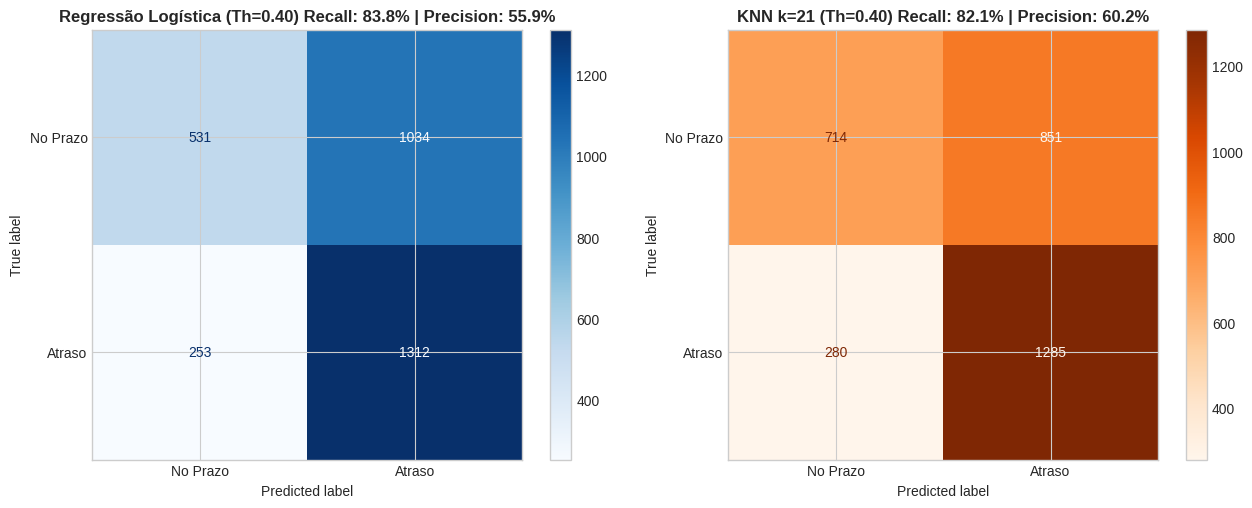

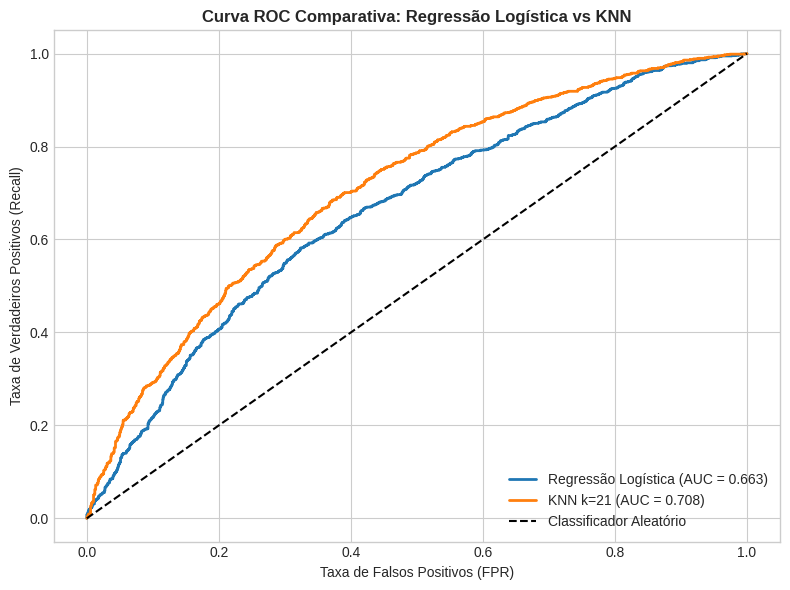

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Prazo', 'Atraso']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"Regressão Logística (Th=0.40) Recall: {recall_score(y_test, y_pred_lr)*100:.1f}% | Precision: {precision_score(y_test, y_pred_lr)*100:.1f}%", fontweight='bold')

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=['No Prazo', 'Atraso']).plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title(f"KNN k=21 (Th=0.40) Recall: {recall_score(y_test, y_pred_knn)*100:.1f}% | Precision: {precision_score(y_test, y_pred_knn)*100:.1f}%", fontweight='bold')

plt.tight_layout()
plt.show()

# Curva ROC Comparativa
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Regressão Logística (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})", color='#1f77b4', lw=2)
plt.plot(fpr_knn, tpr_knn, label=f"KNN k=21 (AUC = {roc_auc_score(y_test, y_proba_knn):.3f})", color='#ff7f0e', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador Aleatório')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC Comparativa: Regressão Logística vs KNN', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7. Interpretação dos Fatores de Risco (Coeficientes da Regressão Logística)
A Regressão Logística fornece interpretabilidade direta através do sinal e magnitude de seus coeficientes:
- **Coeficiente Positivo:** Aumenta o risco de atraso (ex.: maior distância física entre comprador e vendedor, valor alto de frete ou tempo de aprovação).
- **Coeficiente Negativo:** Reduz o risco de atraso (ex.: vendedor e cliente no mesmo estado federativo, prazos estimados mais amplos e conservadores).


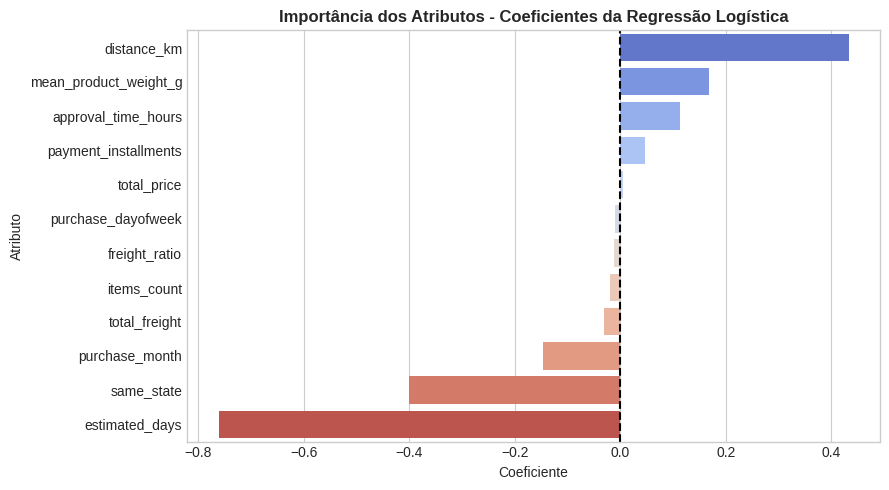

In [14]:
coef_df = pd.DataFrame({
    'Atributo': features,
    'Coeficiente': model_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Coeficiente', y='Atributo', palette='coolwarm')
plt.title('Importância dos Atributos - Coeficientes da Regressão Logística', fontweight='bold')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()
